In [1]:
import os
import tqdm
import time
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.optim.lr_scheduler import _LRScheduler
import torch.optim as optim
from torch.utils import data as torch_data

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix as sklearn_confusion_matrix
from sklearn.metrics import classification_report

import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import copy

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
if torch.cuda.is_available():
  device = torch.device("cuda")
elif torch.backends.mps.is_available():
  device = torch.device("mps")
else:
  device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


# DatacenterDataset code

In [4]:
class DatacenterDataset(Dataset):
    def __init__(self, src, trg, class_names):
        self.src = torch.tensor(src, dtype=torch.float32)
        self.trg = torch.tensor(trg, dtype=torch.long)
        self.class_names = class_names

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return self.src[idx], self.trg[idx]

# Load ML Data


In [5]:
seed = 2022
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

max_workers = 0
batch_size = 32

In [6]:
def split_data_combined_dataset(npz_path):

  ml_data = np.load(npz_path)
  X, y, model = ml_data["X"], ml_data["y"], ml_data["model"]

  print(X.shape, y.shape, model.shape)

  class_map = (
      pd.DataFrame({"y": y, "model": model})
      .drop_duplicates()
      .sort_values("y")
  )

  assert class_map["y"].is_unique
  assert class_map["model"].is_unique
  assert np.array_equal(class_map["y"].values, np.arange(len(class_map)))

  class_names = class_map["model"].values

  # First split: train+val vs test
  sss1 = StratifiedShuffleSplit(
      n_splits=1,
      test_size=0.2,
      random_state=37
  )

  for train_val_idx, test_idx in sss1.split(X, y):
      X_train_val, X_test = X[train_val_idx], X[test_idx]
      y_train_val, y_test = y[train_val_idx], y[test_idx]

  # Second split: train vs validation
  sss2 = StratifiedShuffleSplit(
      n_splits=1,
      test_size=0.2,
      random_state=38
  )

  for train_idx, val_idx in sss2.split(X_train_val, y_train_val):
      X_train, X_val = X_train_val[train_idx], X_train_val[val_idx]
      y_train, y_val = y_train_val[train_idx], y_train_val[val_idx]

  print("Train:", X_train.shape, y_train.shape)
  print("Val:  ", X_val.shape, y_val.shape)
  print("Test: ", X_test.shape, y_test.shape)

  n_classes = len(np.unique(y_train))

  # Standardize using train only
  scaler = StandardScaler()

  X_train = scaler.fit_transform(
      X_train.reshape(-1, X_train.shape[-1])
  ).reshape(X_train.shape)

  X_val = scaler.transform(
      X_val.reshape(-1, X_val.shape[-1])
  ).reshape(X_val.shape)

  X_test = scaler.transform(
      X_test.reshape(-1, X_test.shape[-1])
  ).reshape(X_test.shape)

  # Build datasets
  dset_train = DatacenterDataset(X_train, y_train, class_names)
  dset_val = DatacenterDataset(X_val, y_val, class_names)
  dset_test = DatacenterDataset(X_test, y_test, class_names)

  train_dl_combined = torch_data.DataLoader(
      dset_train,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=True
  )

  val_dl_combined = torch_data.DataLoader(
      dset_val,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=False
  )

  test_dl_combined = torch_data.DataLoader(
      dset_test,
      batch_size=batch_size,
      num_workers=max_workers,
      shuffle=False
  )
  return train_dl_combined, val_dl_combined, test_dl_combined

In [8]:
data_directory_path_combined = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Data/COMBINED"
combined_datasets = []

for _file in os.listdir(data_directory_path_combined):
  if not _file.endswith(".npz"):
    continue
  _filepath = os.path.join(data_directory_path_combined, _file)
  train_dl_combined, val_dl_combined, test_dl_combined = split_data_combined_dataset(_filepath)
  combined_datasets.append({"name": _file, "train_dl": train_dl_combined, "val_dl": val_dl_combined, "test_dl": test_dl_combined})

(18238, 540, 15) (18238,) (18238,)
Train: (11672, 540, 15) (11672,)
Val:   (2918, 540, 15) (2918,)
Test:  (3648, 540, 15) (3648,)
(17767, 540, 15) (17767,) (17767,)
Train: (11370, 540, 15) (11370,)
Val:   (2843, 540, 15) (2843,)
Test:  (3554, 540, 15) (3554,)
(17728, 540, 15) (17728,) (17728,)
Train: (11345, 540, 15) (11345,)
Val:   (2837, 540, 15) (2837,)
Test:  (3546, 540, 15) (3546,)
(17725, 540, 15) (17725,) (17725,)
Train: (11344, 540, 15) (11344,)
Val:   (2836, 540, 15) (2836,)
Test:  (3545, 540, 15) (3545,)
(17741, 540, 15) (17741,) (17741,)
Train: (11353, 540, 15) (11353,)
Val:   (2839, 540, 15) (2839,)
Test:  (3549, 540, 15) (3549,)
(17724, 540, 15) (17724,) (17724,)
Train: (11343, 540, 15) (11343,)
Val:   (2836, 540, 15) (2836,)
Test:  (3545, 540, 15) (3545,)
(17733, 540, 15) (17733,) (17733,)
Train: (11348, 540, 15) (11348,)
Val:   (2838, 540, 15) (2838,)
Test:  (3547, 540, 15) (3547,)


In [9]:
class_names_combined = test_dl_combined.dataset.class_names
print(class_names_combined)

['U3-128' 'U3-32' 'U3-64' 'U4-128' 'U4-32' 'U4-64' 'U5-128' 'U5-32'
 'U5-64' 'bert-base-uncased' 'conv' 'dimenet' 'distilbert-base-uncased'
 'inception3' 'inception4' 'pna' 'resnet101' 'resnet101_v2' 'resnet152'
 'resnet152_v2' 'resnet50' 'resnet50_v1.5' 'schnet' 'vgg11' 'vgg16'
 'vgg19']


# Define Model(s)

In [11]:
class GatedRecurrentModel(nn.Module):
    def __init__(self,
                 input_dim,
                 num_classes,
                 hidden_dim=128,
                 num_layers=2,
                 dropout=0.2,
                 bidirectional=True
                 ):
      super().__init__()
      self.gru = nn.GRU(
          input_size=input_dim,
          hidden_size=hidden_dim,
          num_layers=num_layers,
          dropout=dropout,
          bidirectional=bidirectional,
          batch_first=True
      )
      gru_output_dim = hidden_dim * 2 if bidirectional else hidden_dim

      self.classifier = nn.Sequential(
          nn.LayerNorm(gru_output_dim),
          nn.Linear(gru_output_dim, hidden_dim),
          nn.GELU(),
          nn.Dropout(dropout),
          nn.Linear(hidden_dim, num_classes),
      )

    def forward(self, x):
      # x shape: [batch_size, seq_len, input_dim]
      out, hidden = self.gru(x)

      # Mean pooling over time often works better than only last hidden state
      h = out.mean(dim=1)

      logits = self.classifier(h)
      return logits, hidden

In [12]:
MODEL_CONFIG = {
    "input_dim": 15,
    "num_classes": 26,
    "hidden_dim": 128,
    "num_layers": 2,
    "dropout": 0.2,
    "bidirectional": True,
}

def build_gru():
    return GatedRecurrentModel(
        **MODEL_CONFIG,
    )


# Training and Evaluating Functions

In [13]:
def forward_batch(model, batch, device, separate=False):
    if separate:
        x_gpu, x_cpu, labels = batch
        x_gpu = x_gpu.to(device)
        x_cpu = x_cpu.to(device)
        labels = labels.to(device)
        outputs = model(x_gpu, x_cpu)
    else:
        features, labels = batch
        features = features.to(device)
        labels = labels.to(device)
        outputs = model(features)

    return outputs, labels

In [14]:
def train_epoch(model, train_loader, loss_fn, optimizer, separate=False):
    model.train()

    epoch_loss = 0.0
    correct_total = 0
    sample_total = 0

    for batch in tqdm.tqdm(train_loader):
        optimizer.zero_grad()

        (outputs, hidden), labels = forward_batch(model, batch, device, separate=separate)

        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        batch_size = labels.size(0)
        epoch_loss += loss.item() * batch_size
        correct_total += (preds == labels).sum().item()
        sample_total += batch_size

    return epoch_loss / sample_total, correct_total / sample_total

In [26]:
def evaluate(model, test_loader, loss_fn, separate=False):
    model.eval()

    epoch_loss = 0.0
    correct_total = 0
    sample_total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm.tqdm(test_loader):
            (outputs, hidden), labels = forward_batch(model, batch, device, separate=separate)

            loss = loss_fn(outputs, labels)
            preds = torch.argmax(outputs, dim=1)

            batch_size = labels.size(0)
            epoch_loss += loss.item() * batch_size
            correct_total += (preds == labels).sum().item()
            sample_total += batch_size

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return epoch_loss / sample_total, correct_total / sample_total, all_labels, all_preds

In [27]:
def train_and_evaluate(
    train_dl,
    val_dl,
    model,
    loss_fn,
    optimizer,
    num_epochs,
    patience=100,
    separate=False,
):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    best_acc = 0
    trials = 0
    best_labels = None
    best_preds = None

    best_state = None

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_accuracy = train_epoch(
            model=model,
            train_loader=train_dl,
            loss_fn=loss_fn,
            optimizer=optimizer,
            separate=separate,
        )

        val_loss, val_accuracy, _, _ = evaluate(
            model=model,
            test_loader=val_dl,
            loss_fn=loss_fn,
            separate=separate,
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        end_time = time.time()

        if epoch % 5 == 0:
            print(f"Epoch [{epoch + 1}/{num_epochs}] | Time: {end_time - start_time:.2f}s")
            print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
            print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_accuracy:.4f}")

        if val_accuracy > best_acc:
            best_acc = val_accuracy
            trials = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            trials += 1
            if trials >= patience:
                print(f"Early stopping on epoch {epoch + 1}")
                print(f"Best validation accuracy: {best_acc:.2%}")
                break
    if best_state is not None:
      model.load_state_dict(best_state)

    return (
        np.array(train_losses),
        np.array(val_losses),
        np.array(train_accuracies),
        np.array(val_accuracies),
    )

# Visualize Functions

In [17]:
def plot_training_curves_from_result(result):
    """
    Plot train/validation loss and accuracy curves for one result dictionary.
    """

    model_name = result["model_name"]
    dataset_name = result["dataset_name"]

    train_losses = result["train_losses"]
    val_losses = result["val_losses"]
    train_accs = result["train_accs"]
    val_accs = result["val_accs"]

    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train loss")
    plt.plot(epochs, val_losses, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label="Train accuracy")
    plt.plot(epochs, val_accs, label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.suptitle(
        f"{model_name} on {dataset_name}\n"
        f"Test accuracy: {result['test_acc']:.4f}, Test loss: {result['test_loss']:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [18]:
def plot_confusion_matrix_from_result(
    result,
    class_names=None,
    normalize=False,
    figsize=(12, 10),
):
    """
    Plot confusion matrix for one result dictionary.

    If normalize=True, rows are normalized by true class count.
    """

    model_name = result["model_name"]
    dataset_name = result["dataset_name"]

    y_true = result["test_labels"]
    y_pred = result["test_preds"]

    cm = sklearn_confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
        title_extra = "Normalized confusion matrix"
    else:
        fmt = "d"
        title_extra = "Confusion matrix"

    plt.figure(figsize=figsize)

    sns.heatmap(
        cm,
        annot=False,
        fmt=fmt,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(
        f"{title_extra}\n{model_name} on {dataset_name}\n"
        f"Test accuracy: {result['test_acc']:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [19]:
def plot_best_and_worst_runs(
    results,
    metric="test_acc",
    class_names=None,
    normalize_cm=False,
):
    """
    Finds the best and worst runs and plots:
      1. Train/validation loss and accuracy curves
      2. Test-set confusion matrix
    """

    best_result, worst_result = get_best_and_worst_results(results, metric=metric)

    print("Best run:")
    print("Model:", best_result["model_name"])
    print("Dataset:", best_result["dataset_name"])
    print("Test accuracy:", best_result["test_acc"])
    print("Test loss:", best_result["test_loss"])
    print()

    plot_training_curves_from_result(best_result)
    plot_confusion_matrix_from_result(
        best_result,
        class_names=class_names,
        normalize=normalize_cm,
    )

    print("Worst run:")
    print("Model:", worst_result["model_name"])
    print("Dataset:", worst_result["dataset_name"])
    print("Test accuracy:", worst_result["test_acc"])
    print("Test loss:", worst_result["test_loss"])
    print()

    plot_training_curves_from_result(worst_result)
    plot_confusion_matrix_from_result(
        worst_result,
        class_names=class_names,
        normalize=normalize_cm,
    )

    return best_result, worst_result

# Main Function

In [20]:
def count_model_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

In [21]:
def main(
    dataset_ls,
    model_builder,
    model_name,
    separate=False,
    num_epochs=10,
    learning_rate=1e-4,
    save_model=True,
    patience=100,
):
    results = []

    MODEL_SAVE_DIR = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models"

    os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

    for dataset in dataset_ls:
        dataset_name = dataset["name"]
        print(f"Training {model_name} on {dataset_name}")

        model = model_builder().to(device)

        total_params, trainable_params = count_model_parameters(model)

        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")

        loss_fn = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        # More accurate timing on GPU
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        train_losses, val_losses, train_accs, val_accs = train_and_evaluate(
            train_dl=dataset["train_dl"],
            val_dl=dataset["val_dl"],
            model=model,
            loss_fn=loss_fn,
            optimizer=optimizer,
            num_epochs=num_epochs,
            separate=separate,
            patience=patience,
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end_time = time.perf_counter()

        training_duration_sec = end_time - start_time
        training_duration_min = training_duration_sec / 60

        test_loss, test_acc, test_labels, test_preds = evaluate(
            model=model,
            test_loader=dataset["test_dl"],
            loss_fn=loss_fn,
            separate=separate,
        )

        save_path = None

        if save_model:
            safe_dataset_name = dataset_name.replace(".npz", "")
            save_path = os.path.join(MODEL_SAVE_DIR, f"{model_name}_{safe_dataset_name}.pt")
            torch.save(model.state_dict(), save_path)
            print(f"Saved model to {save_path}")

        results.append({
          "model_name": model_name,
          "dataset_name": dataset_name,

          # Performance
          "test_loss": test_loss,
          "test_acc": test_acc,
          "best_val_acc": max(val_accs),
          "final_val_acc": val_accs[-1],
          "final_train_acc": train_accs[-1],
          "num_epochs_run": len(train_losses),

          # Training curves
          "train_losses": train_losses,
          "val_losses": val_losses,
          "train_accs": train_accs,
          "val_accs": val_accs,

          # Predictions
          "test_labels": test_labels,
          "test_preds": test_preds,

          # Efficiency / complexity
          "total_params": total_params,
          "trainable_params": trainable_params,
          "training_duration_sec": training_duration_sec,
          "training_duration_min": training_duration_min,
          "avg_epoch_time_sec": training_duration_sec / len(train_losses),

          # Saved model
          "model_path": save_path,
        })

        print(f"Test accuracy: {test_acc:.4f}")
        print(f"Training duration: {training_duration_min:.2f} min")
        print(f"Average epoch time: {training_duration_sec / len(train_losses):.2f} sec")
        print("-" * 80)

    return results

In [22]:
def get_best_and_worst_results(results, metric="test_acc"):
    """
    Returns the best and worst result dictionaries based on a metric.

    For accuracy, higher is better.
    For loss, lower is better.
    """

    if len(results) == 0:
        raise ValueError("results list is empty.")

    if metric in ["test_acc", "val_acc", "accuracy"]:
        best_result = max(results, key=lambda r: r[metric])
        worst_result = min(results, key=lambda r: r[metric])

    elif metric in ["test_loss", "val_loss", "loss"]:
        best_result = min(results, key=lambda r: r[metric])
        worst_result = max(results, key=lambda r: r[metric])

    else:
        raise ValueError(f"Unknown metric: {metric}")

    return best_result, worst_result

In [23]:
def results_to_summary_df(results):
    rows = []

    for r in results:
        rows.append({
            "model_name": r["model_name"],
            "dataset_name": r["dataset_name"],
            "test_acc": r["test_acc"],
            "test_loss": r["test_loss"],
            "best_val_acc": r["best_val_acc"],
            "final_val_acc": r["final_val_acc"],
            "final_train_acc": r["final_train_acc"],
            "num_epochs_run": r["num_epochs_run"],
            "total_params": r["total_params"],
            "trainable_params": r["trainable_params"],
            "training_duration_sec": r["training_duration_sec"],
            "training_duration_min": r["training_duration_min"],
            "avg_epoch_time_sec": r["avg_epoch_time_sec"],
            "model_path": r["model_path"],
        })

    return pd.DataFrame(rows)

# Training and Evaluation Runs

## Define Hyperparamters

In [24]:
learning_rate = 1e-4
num_epochs = 50
patience = 7

### GRU

In [28]:
results_gru = main(
    dataset_ls=combined_datasets,
    model_builder=build_gru,
    model_name="GRU",
    separate=False,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    save_model=True,
    patience=patience,
)

Training GRU on 60-start-1-cpu-gpu.npz
Total parameters: 444,570
Trainable parameters: 444,570


100%|██████████| 92/92 [00:00<00:00, 255.43it/s]


Epoch [1/50] | Time: 3.26s
Train Loss: 1.5821 | Train Accuracy: 0.5224
Val Loss:   1.0593 | Val Accuracy:   0.6700


100%|██████████| 92/92 [00:00<00:00, 266.65it/s]


Epoch [6/50] | Time: 3.20s
Train Loss: 0.6158 | Train Accuracy: 0.7678
Val Loss:   0.5822 | Val Accuracy:   0.7807


...

Epoch [41/50] | Time: 3.09s
Train Loss: 0.1657 | Train Accuracy: 0.9339
Val Loss:   0.2034 | Val Accuracy:   0.9161


100%|██████████| 89/89 [00:00<00:00, 266.50it/s]


Epoch [46/50] | Time: 3.10s
Train Loss: 0.1477 | Train Accuracy: 0.9388
Val Loss:   0.1622 | Val Accuracy:   0.9383


100%|██████████| 111/111 [00:00<00:00, 264.08it/s]

Saved model to /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/GRU_60-random-5-cpu-gpu.pt
Test accuracy: 0.9394
Training duration: 2.59 min
Average epoch time: 3.11 sec
--------------------------------------------------------------------------------


Best run:
Model: GRU
Dataset: 60-middle-1-cpu-gpu.npz
Test accuracy: 0.9572312886888014
Test loss: 0.10632746157246355



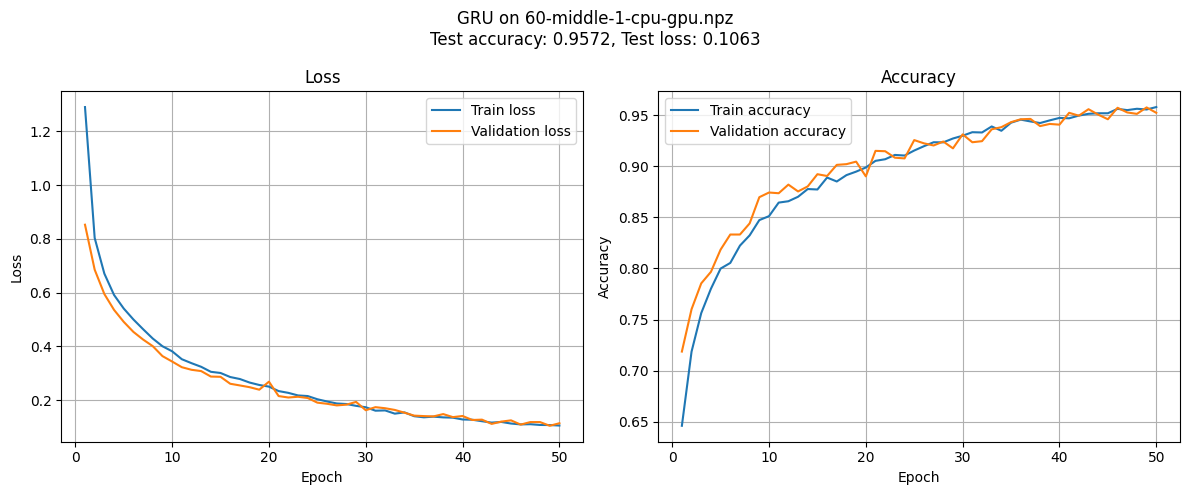

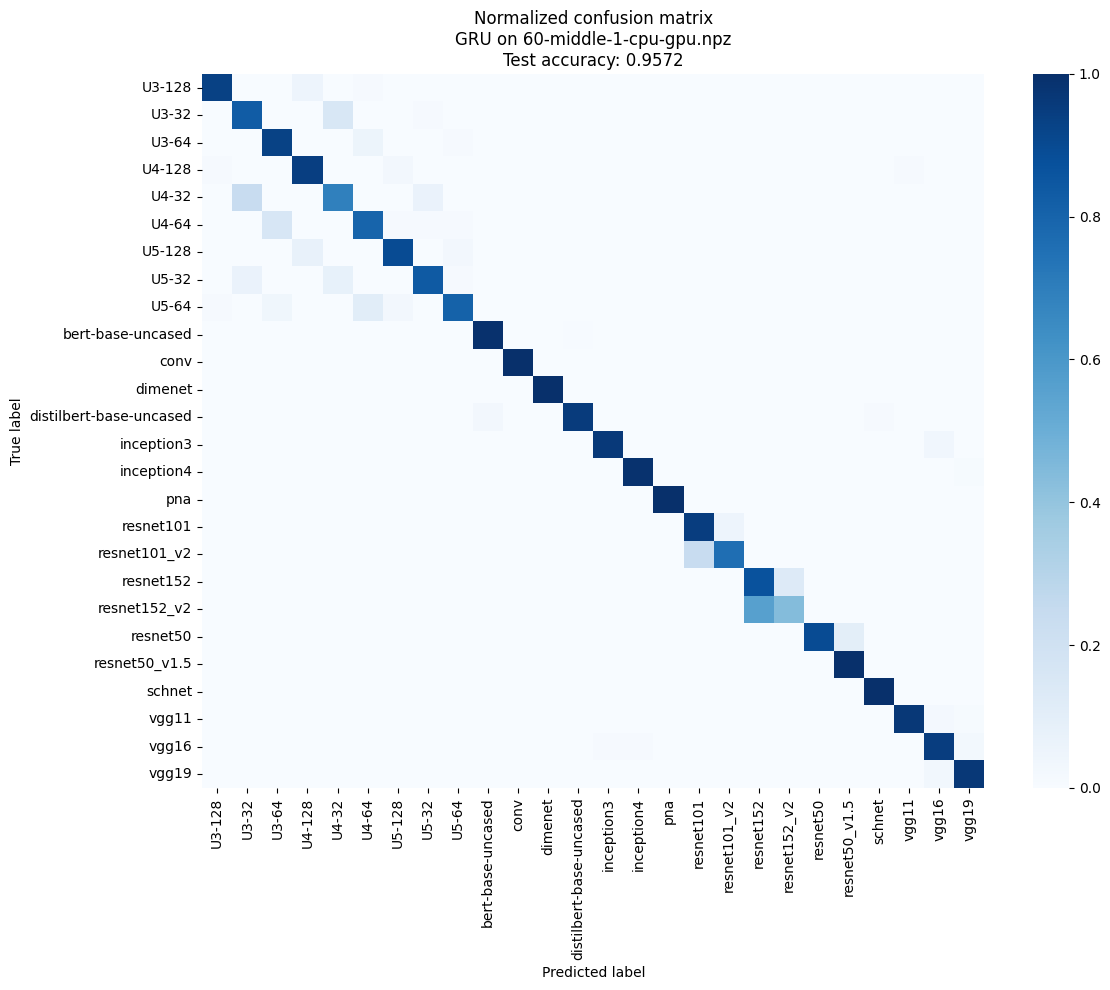

Worst run:
Model: GRU
Dataset: 60-start-1-cpu-gpu.npz
Test accuracy: 0.8220942982456141
Test loss: 0.4606125561291711



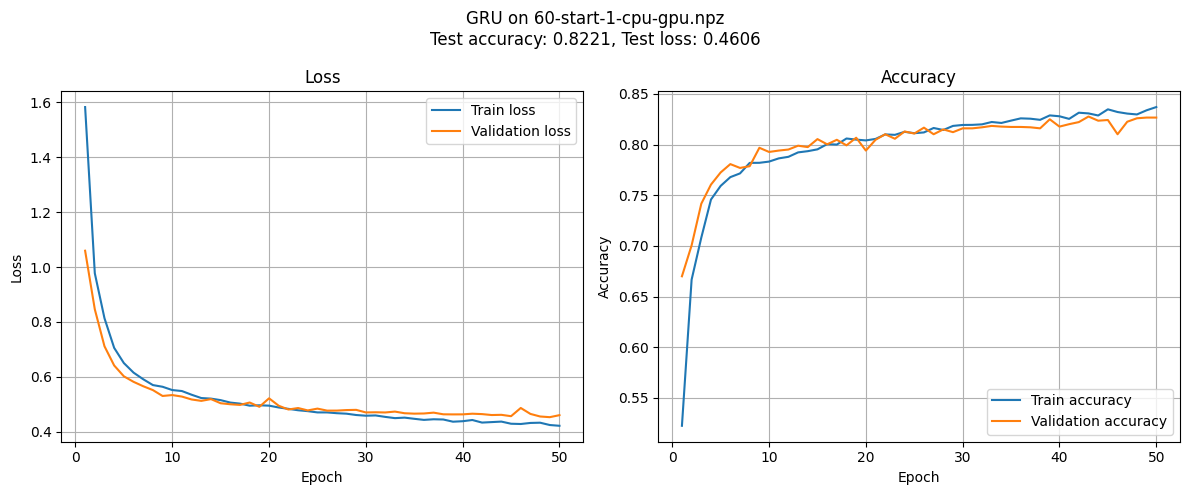

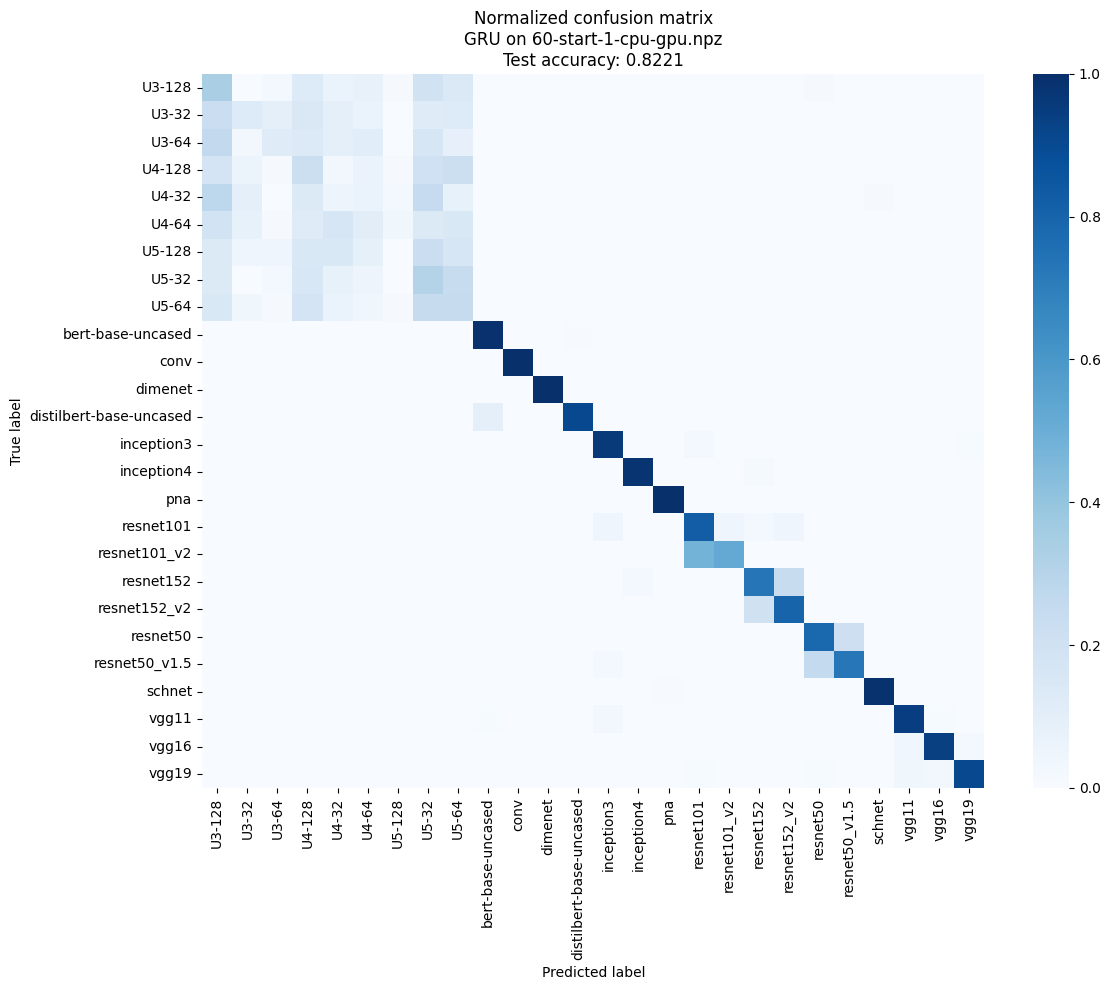

In [29]:
best_result, worst_result = plot_best_and_worst_runs(
    results_gru,
    metric="test_acc",
    class_names=class_names_combined,
    normalize_cm=True,
)

In [30]:
summary_df = results_to_summary_df(results_gru)
summary_df

,model_name,dataset_name,test_acc,test_loss,best_val_acc,final_val_acc,final_train_acc,num_epochs_run,total_params,trainable_params,training_duration_sec,training_duration_min,avg_epoch_time_sec,model_path
0,GRU,60-start-1-cpu-gpu.npz,0.822094,0.460613,0.827622,0.826594,0.836960,50,444570,444570,159.825179,2.663753,3.196504,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
1,GRU,60-middle-1-cpu-gpu.npz,0.957231,0.106327,0.957791,0.952515,0.958135,50,444570,444570,155.397900,2.589965,3.107958,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
2,GRU,60-random-1-cpu-gpu.npz,0.944444,0.151193,0.945365,0.945365,0.944381,50,444570,444570,154.803746,2.580062,3.096075,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
3,GRU,60-random-2-cpu-gpu.npz,0.917348,0.196865,0.928420,0.928068,0.931153,43,444570,444570,133.182888,2.219715,3.097276,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
4,GRU,60-random-3-cpu-gpu.npz,0.934066,0.167128,0.935541,0.926383,0.939928,46,444570,444570,142.833222,2.380554,3.105070,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
5,GRU,60-random-4-cpu-gpu.npz,0.941044,0.151828,0.944993,0.944993,0.949396,50,444570,444570,155.414173,2.590236,3.108283,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
6,GRU,60-random-5-cpu-gpu.npz,0.939385,0.153961,0.943270,0.932699,0.943074,50,444570,444570,155.364222,2.589404,3.107284,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...


In [31]:
summary_df.groupby("model_name").mean("test_acc").sort_values("test_acc", ascending=False)

,test_acc,test_loss,best_val_acc,final_val_acc,final_train_acc,num_epochs_run,total_params,trainable_params,training_duration_sec,training_duration_min,avg_epoch_time_sec
model_name,,,,,,,,,,,
GRU,0.92223,0.198273,0.926143,0.922374,0.929004,48.428571,444570.0,444570.0,150.974476,2.516241,3.116922
